# **<center>Анализ CTR рекламных объявлений</center>**

## **Цель проекта**

### Анализ эффективности рекламных объявлений на основе показателя CTR (Click-Through Rate) и выявление наиболее успешных рекламных кампаний

## **Подготовка данных**

### Импорт необходимых для работы библиотек, настройка отоброжения графиков, а также выключение warning

In [252]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline
sns.set(font_scale=2,
        style="whitegrid",
        rc={'figure.figsize':(20,7)})

import warnings
warnings.filterwarnings('ignore')

### Считывание данных с .csv файла

In [140]:
df = pd.read_csv('ads_data.csv', parse_dates = ['date','time'])

### Вывод первых строк таблицы

In [141]:
df.head(3)

,date,time,event,platform,ad_id,client_union_id,campaign_union_id,ad_cost_type,ad_cost,has_video,target_audience_count
0,2019-04-01,2019-04-01 00:00:48,view,android,45061,34734,45061,CPM,200.6,0,1955269
1,2019-04-01,2019-04-01 00:00:48,view,web,121288,121288,121288,CPM,187.4,0,232011
2,2019-04-01,2019-04-01 00:01:03,view,android,102737,102535,102564,CPC,60.7,0,4410


### Количество строк и столбцов

In [142]:
print(f'Строк - {df.shape[0]}, Столбцов - {df.shape[1]}')

Строк - 1000000, Столбцов - 11


### Типы данных

In [143]:
df.dtypes

date                     datetime64[ns]
time                     datetime64[ns]
event                            object
platform                         object
ad_id                             int64
client_union_id                   int64
campaign_union_id                 int64
ad_cost_type                     object
ad_cost                         float64
has_video                         int64
target_audience_count             int64
dtype: object

### Пропущенные значения

In [144]:
if df.isna().sum().sum() == 0:
    print('Не обнаружено')
else:
    df.isna().sum()

Не обнаружено


## **Составление таблицы CTR**

### Создаем таблицу кликов на объявления, с группировкой по дате, платформе и id объявления

In [198]:
df_clicks = df \
    .query("event == 'click'") \
    .groupby(['date', 'platform', 'ad_id'], as_index = False) \
    .agg({'client_union_id' : 'count'}) \
    .rename(columns = {'client_union_id' : 'count_clicks'})

### Аналогично создаем таблицу показов объявлений

In [199]:
df_views = df \
    .query("event == 'view'") \
    .groupby(['date', 'platform', 'ad_id'], as_index = False) \
    .agg({'client_union_id' : 'count'}) \
    .rename(columns = {'client_union_id' : 'count_views'})

### Создаем общую таблицу с CTR

In [206]:
df_ctr = df_clicks.merge(df_views, on = ['date', 'platform', 'ad_id'])
df_ctr['ctr'] = df_ctr.count_clicks / df_ctr.count_views

### Выведем первые строки созданной таблицы

In [207]:
df_ctr.head(3)

,date,platform,ad_id,count_clicks,count_views,ctr
0,2019-04-01,android,3,2,78,0.025641
1,2019-04-01,android,4922,9,622,0.014469
2,2019-04-01,android,4933,5,327,0.015291


## **Разведочный анализ**

### Выведем первые 10 строк полученной таблицы с самыми высокими CTR

In [208]:
df_ctr.sort_values('ctr', ascending = False).head(10)

,date,platform,ad_id,count_clicks,count_views,ctr
1093,2019-04-05,web,117164,2,1,2.0
1146,2019-04-06,ios,111122,3,2,1.5
1156,2019-04-06,web,30962,1,1,1.0
817,2019-04-05,android,30168,1,1,1.0
335,2019-04-03,android,10629,1,1,1.0
342,2019-04-03,android,25697,1,1,1.0
983,2019-04-05,ios,98569,1,1,1.0
409,2019-04-03,ios,7358,1,1,1.0
667,2019-04-04,ios,42507,2,2,1.0
411,2019-04-03,ios,13750,1,1,1.0


### Удалим 2 первые строки из таблицы (данные логи с ошибкой, так как ctr <= 1)

In [209]:
old_count_rows = df_ctr.shape[0]
df_ctr = df_ctr.drop([1093, 1146])
if df_ctr.shape[0] == old_count_rows - 2:
    print('Строки успешно удалены')

Строки успешно удалены


### Далее будем работать с объявлениями, количество показов которых больше 20 процентиля (не будем учитывать объявления с маленьким количеством показов, так как поведение CTR там менее предсказуемо и статистически менее занчимо)

In [210]:
print(f'Начальное количество строк {df_ctr.shape[0]}')
views_20_quantile = df_ctr.count_views.quantile(0.20)
df_ctr = df_ctr.query(f"count_views > {views_20_quantile}")
print(f'Количество строк после фильтрации {df_ctr.shape[0]}')

Начальное количество строк 1167
Количество строк после фильтрации 919


### Выведем топ 10 рекламных объявлений по их среднему CTR

In [213]:
top_10_ctr = df_ctr \
    .groupby('ad_id', as_index = False) \
    .agg({'ctr' : 'mean'}) \
    .rename(columns = {'ctr' : 'mean_ctr'}) \
    .sort_values('mean_ctr', ascending = False) \
    .head(10)
top_10_ctr

,ad_id,mean_ctr
352,112583,0.300712
267,46639,0.183206
148,38058,0.173913
208,43522,0.172414
378,116698,0.166667
302,104678,0.155556
337,110414,0.133333
47,18681,0.133333
82,26633,0.125000
114,32364,0.125000


### Посмотрим количетсво просмотров и кликов для найденного топа

In [215]:
df_ctr \
    .merge(top_10_ctr, on = 'ad_id') \
    .sort_values('mean_ctr', ascending = False)

,date,platform,ad_id,count_clicks,count_views,ctr,mean_ctr
14,2019-04-06,ios,112583,4520,14598,0.309631,0.300712
15,2019-04-06,web,112583,2916,9872,0.295381,0.300712
10,2019-04-05,android,112583,45648,151695,0.300920,0.300712
11,2019-04-05,ios,112583,27303,90707,0.301002,0.300712
12,2019-04-05,web,112583,18066,60409,0.299061,0.300712
13,2019-04-06,android,112583,7314,24521,0.298275,0.300712
0,2019-04-02,android,46639,17,94,0.180851,0.183206
2,2019-04-02,web,46639,4,49,0.081633,0.183206
3,2019-04-03,android,46639,7,28,0.250000,0.183206
1,2019-04-02,ios,46639,13,59,0.220339,0.183206


### У объявления с id = 112583 самый большой CTR, при этом самые большие количества кликов и показов. Найдем id данной рекламной кампании

In [234]:
df.query("ad_id == 112583").campaign_union_id.reset_index().head(1)

,index,campaign_union_id
0,120248,112260


### Посмотрим на количество рекламных объявлений у данной кампании

In [231]:
df.query("campaign_union_id == 112260").ad_id.nunique()

1

### Также посмотрим на среднее количество показов и кликов у данного объявления

In [247]:
print(f'Среднее количество кликов = {df_ctr.query("ad_id == 112583").count_clicks.mean()}')
print(f'Среднее количество показов = {df_ctr.query("ad_id == 112583").count_views.mean()}')

Среднее количество кликов = 17627.833333333332
Среднее количество показов = 58633.666666666664


### Далее найдем среднее количество рекламных объявлений у всех кампаний

In [238]:
ad_id_mean = df \
    .groupby('campaign_union_id', as_index = False) \
    .ad_id.nunique().ad_id.mean()
print(f'Cреднее количество рекламных объявлений у всех кампаний {ad_id_mean}')

Cреднее количество рекламных объявлений у всех кампаний 1.0616061606160616


### Также найдем среднее количество показов и кликов у всех объявлений

In [301]:
df_mean_counts = df_ctr \
    .groupby('ad_id', as_index = False) \
    .agg({'count_clicks' : 'mean', 'count_views' : 'mean'}) \
    .rename(columns = {'count_clicks' : 'mean_count_clicks', 'count_views' : 'mean_count_views'})
print(f'Среднее количество кликов = {df_mean_counts.mean_count_clicks.mean()}')
print(f'Среднее количество показов = {df_mean_counts.mean_count_views.mean()}')

Среднее количество кликов = 43.77244496855346
Среднее количество показов = 367.9977594339623


### Можем сделать вывод что данная рекламная кампания ввела очень удачное рекламное объявление, так как в среднем у всех кампаний 1 объявление, как и у кампании 112260, однако у кампании 112260 самое большое среднее количество просмотров и кликов, а также самый высокий CTR. Посмотрим в какие даты размещалось данное оьбъявление 

In [250]:
df.query("ad_id == 112583").date.unique()

<DatetimeArray>
['2019-04-05 00:00:00', '2019-04-06 00:00:00']
Length: 2, dtype: datetime64[ns]

### Данное объявление было размещено 5 и 6 апреля 2019 года. Учтем это при визуализации, и будем делать графики для данного объявления отдельно. Так как оно сильно превосходит остальные объявления (явлеется лидером), а также оно существенно изменит полученные в будущем графики

## **Визуализация**

### Процентное соотношение кликов к показом для всех объявлений

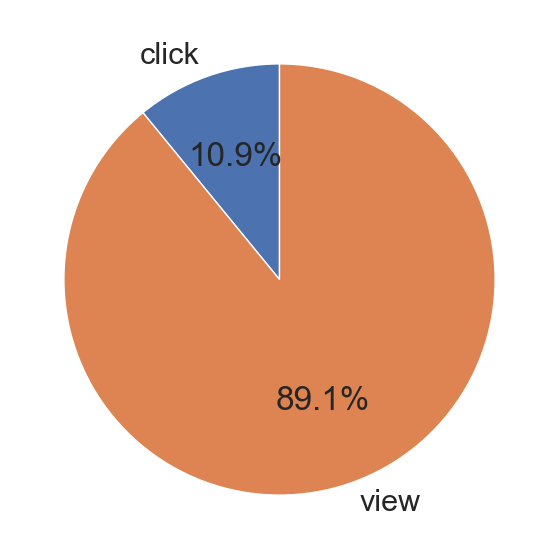

In [266]:
df_for_pie1 = df \
    .groupby('event', as_index = False) \
    .agg({'ad_id' : 'count'}) \
    .rename(columns = {'ad_id' : 'count_ads'})
plt.pie(df_for_pie.count_ads, labels=df_for_pie.event, autopct='%1.1f%%', startangle=90)
plt.show()

### Клики и показы по датам без объявления 112583 и отдельно для него

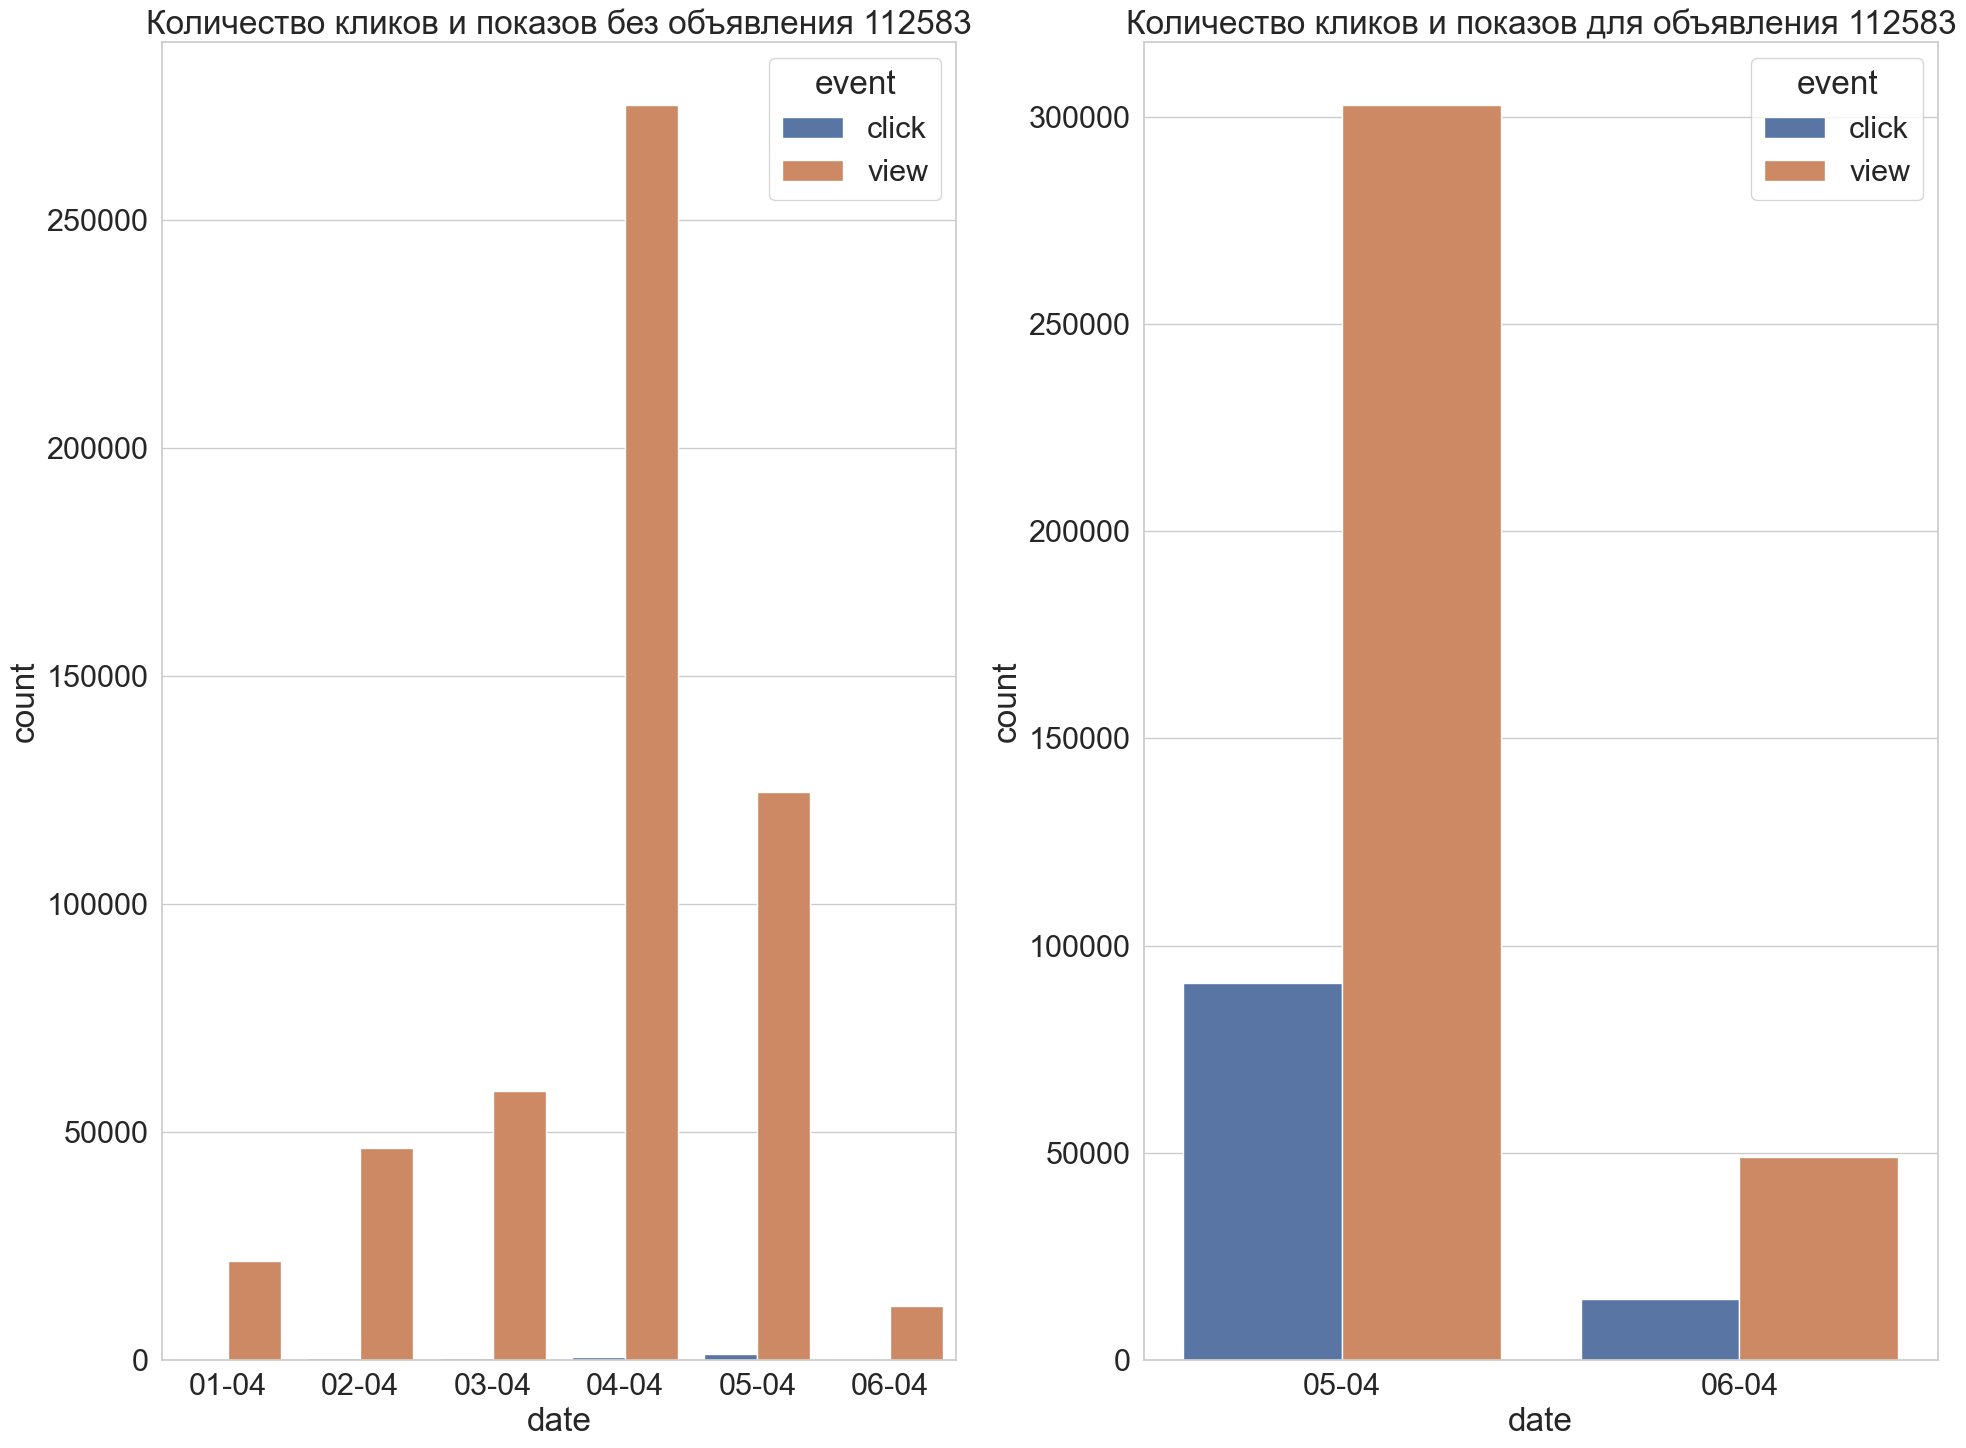

In [306]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 15))

# Первый график
df_for_bar1 = df \
    .query("ad_id != 112583") \
    .groupby(['date', 'event'], as_index = False) \
    .agg({'ad_id' : 'count'}) \
    .rename(columns = {'ad_id' : 'count'})
df_for_bar1['date'] = pd.to_datetime(df_for_bar1['date']).dt.strftime('%d-%m')
sns.barplot(data = df_for_bar1, x = 'date', y = 'count', hue = 'event', ax = ax1)
ax1.set_title('Количество кликов и показов без объявления 112583')

# Второй график
df_for_bar2 = df \
    .query("ad_id == 112583") \
    .groupby(['date', 'event'], as_index = False) \
    .agg({'ad_id' : 'count'}) \
    .rename(columns = {'ad_id' : 'count'})
df_for_bar2['date'] = pd.to_datetime(df_for_bar2['date']).dt.strftime('%d-%m')
sns.barplot(data = df_for_bar2, x = 'date', y = 'count', hue = 'event', ax = ax2)
ax2.set_title('Количество кликов и показов для объявления 112583')

plt.tight_layout()
plt.show()

### CTR по датам без объявления 112583 и отдельно для него

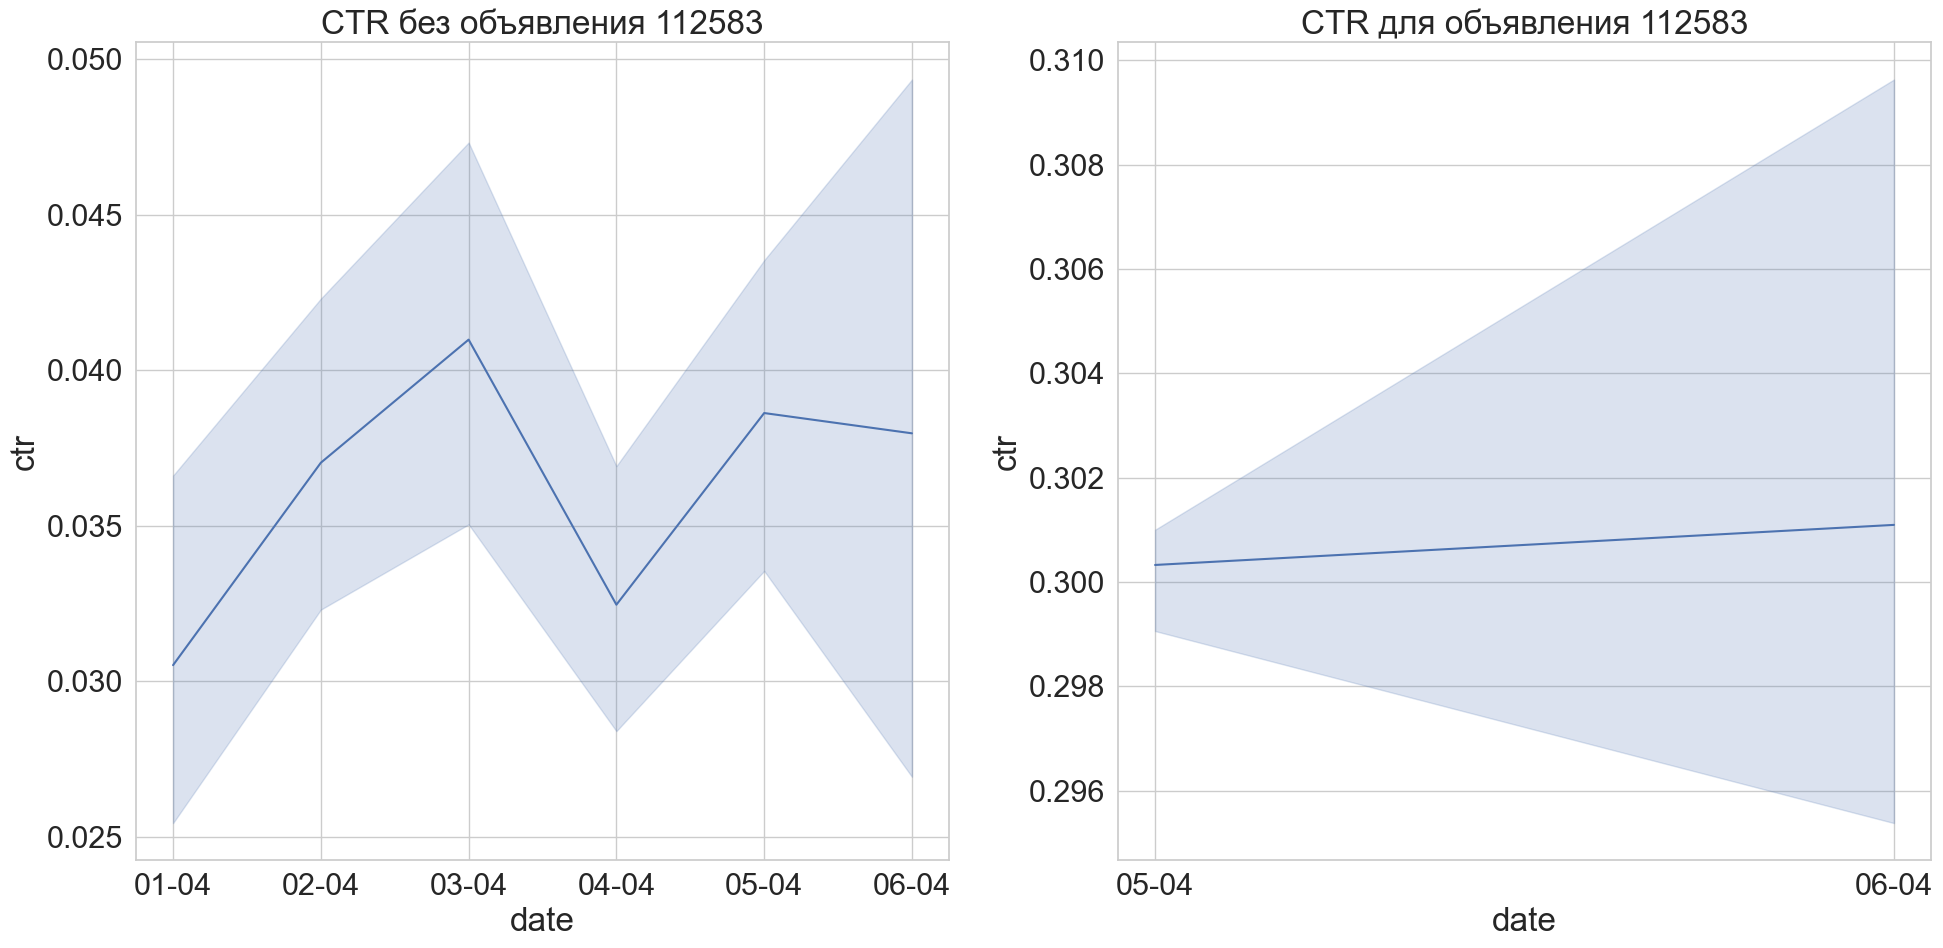

In [305]:
# df_ctr['date'] = pd.to_datetime(df_ctr['date']).dt.strftime('%d-%m')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Первый график
sns.lineplot(data = df_ctr.query("ad_id != 112583"), x = 'date', y = 'ctr', ax = ax1)
ax1.set_title('CTR без объявления 112583')

# Второй график
sns.lineplot(data = df_ctr.query("ad_id == 112583"), x = 'date', y = 'ctr', ax = ax2)
ax2.set_title('CTR для объявления 112583')

plt.tight_layout()
plt.show()

### Распределение CTR без объявления 112583 и отдельно для него

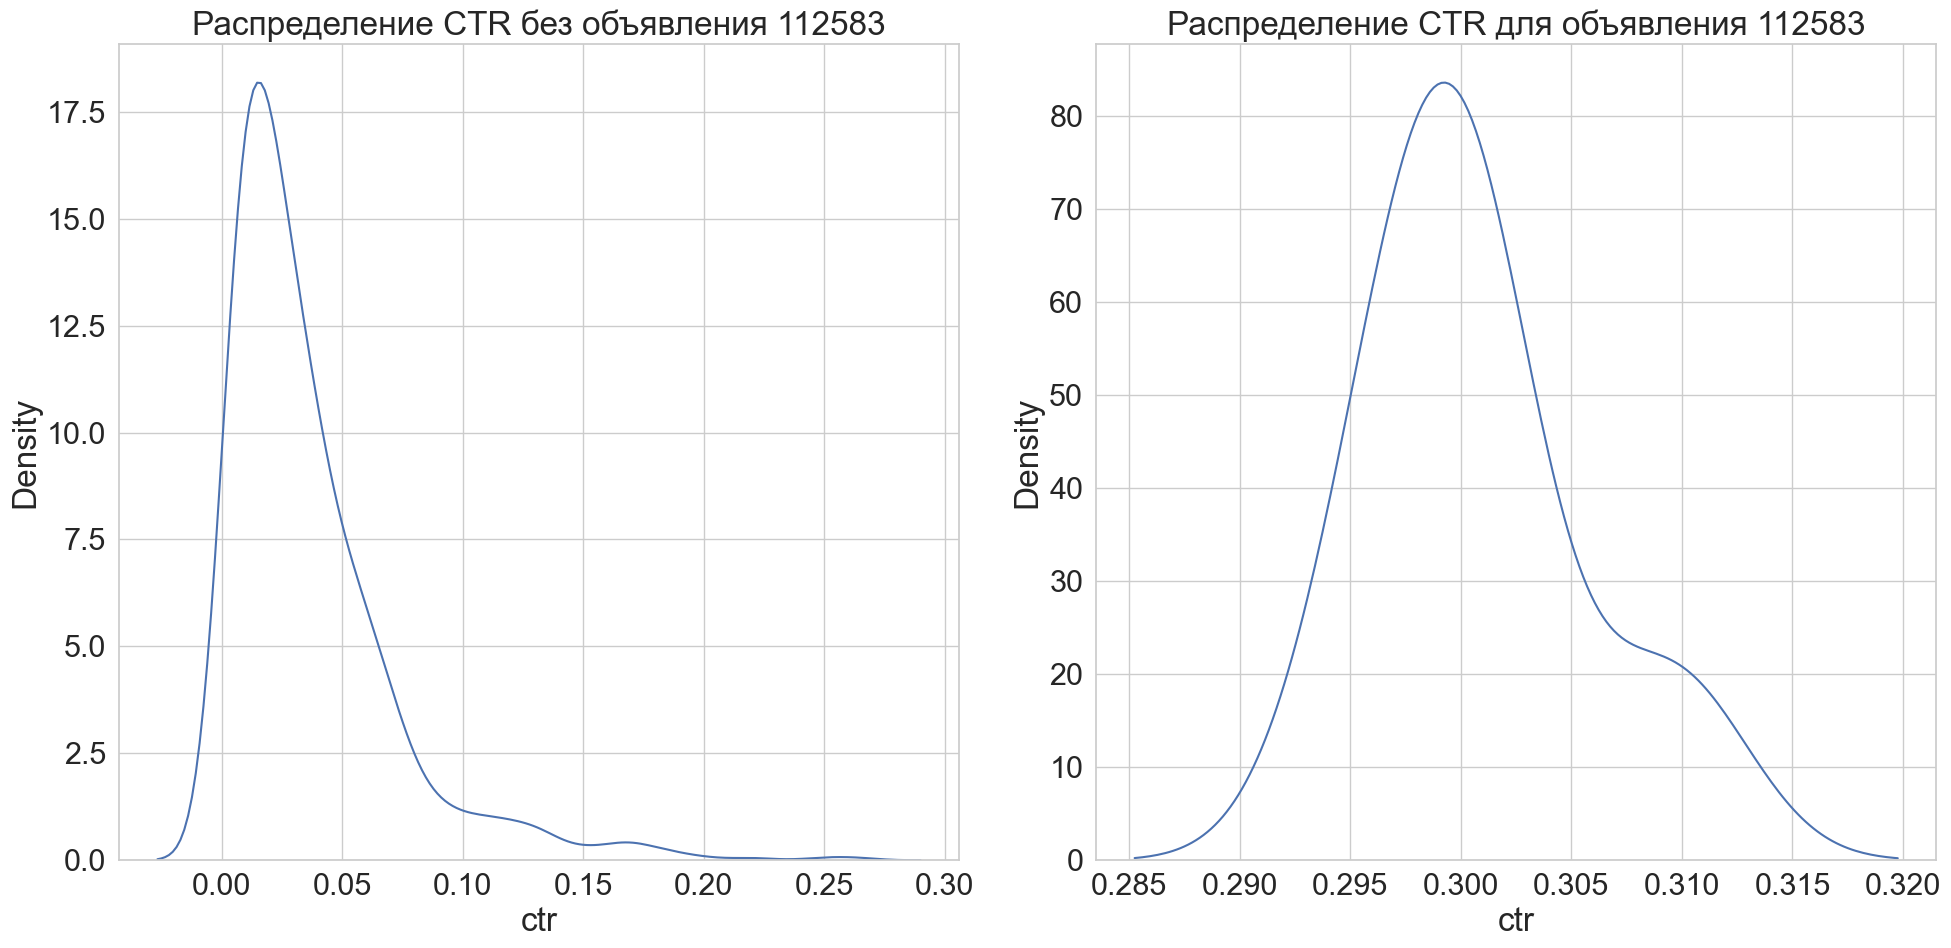

In [296]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Первый график
sns.kdeplot(data = df_ctr.query("ad_id != 112583"), x = "ctr", ax = ax1)
ax1.set_title('Распределение CTR без объявления 112583')

# Второй график
sns.kdeplot(data = df_ctr.query("ad_id == 112583"), x = "ctr", ax = ax2)
ax2.set_title('Распределение CTR для объявления 112583')

plt.tight_layout()
plt.show()

### Распределение CTR по платформам без объявления 112583 и отдельно для него

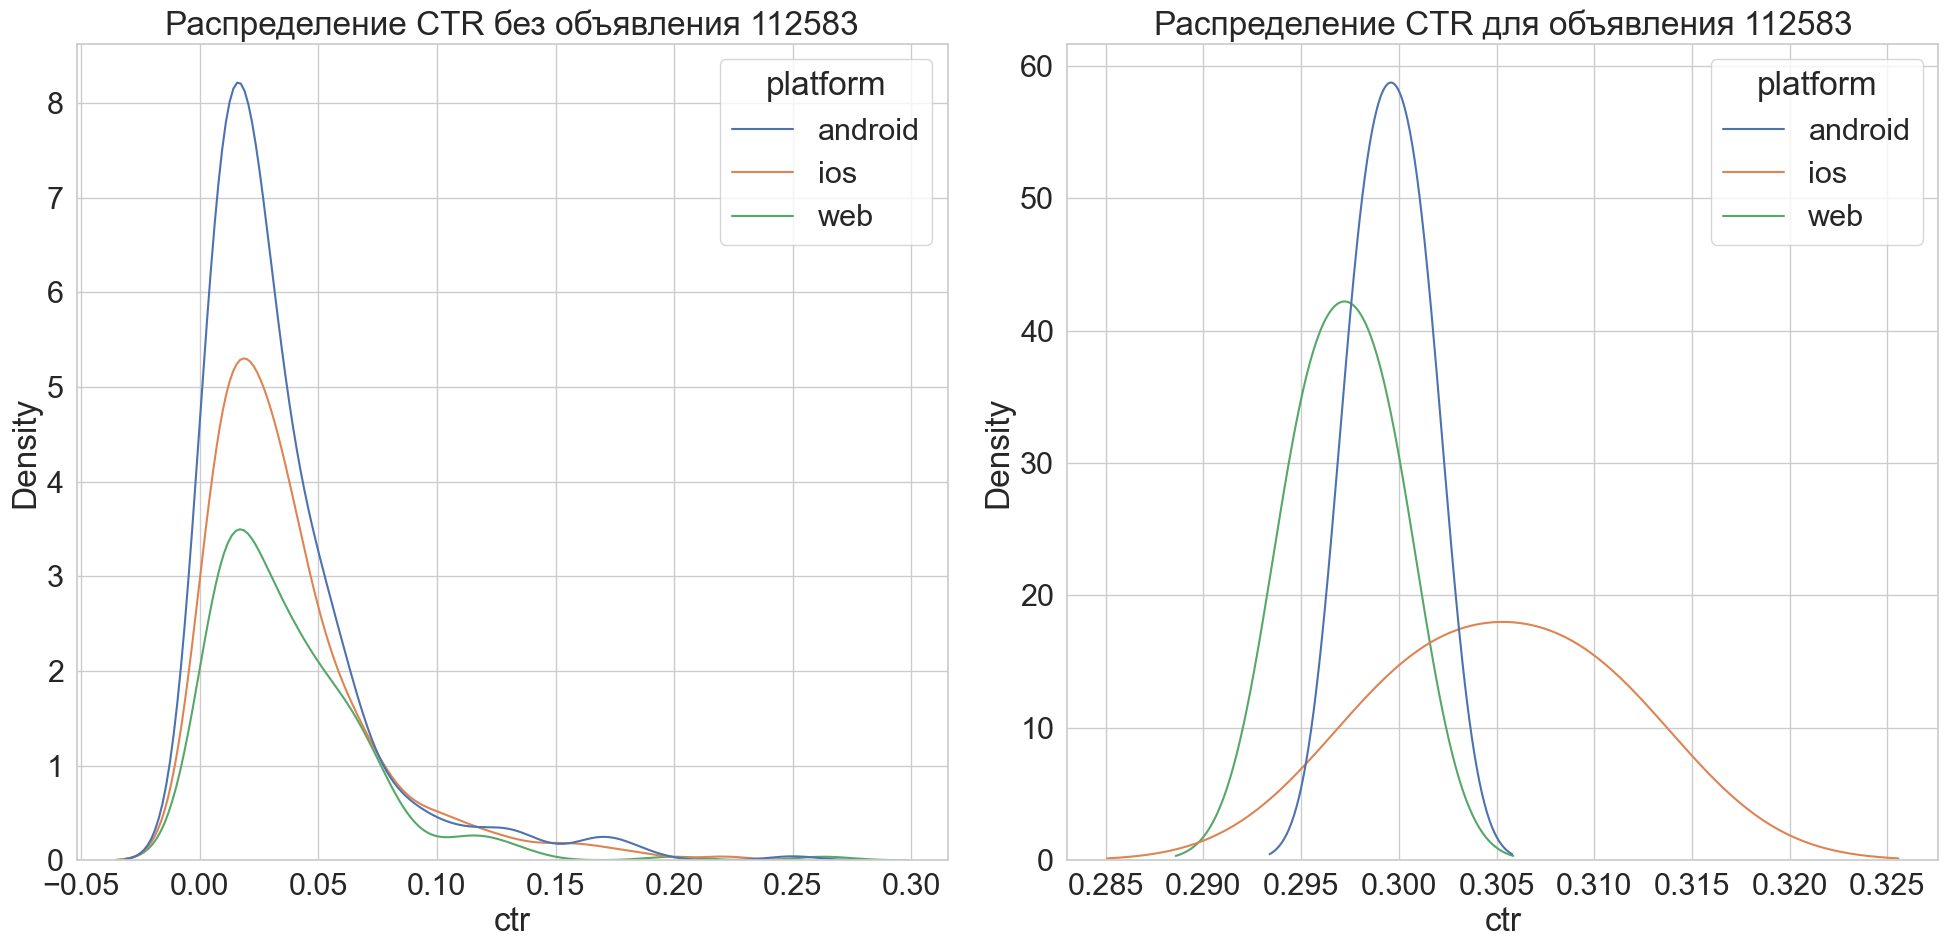

In [300]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Первый график
sns.kdeplot(data = df_ctr.query("ad_id != 112583"), x = "ctr", hue='platform', ax = ax1)
ax1.set_title('Распределение CTR без объявления 112583')

# Второй график
sns.kdeplot(data = df_ctr.query("ad_id == 112583"), x = "ctr", hue='platform', ax = ax2)
ax2.set_title('Распределение CTR для объявления 112583')

plt.tight_layout()
plt.show()

## **Итоги проекта**

**Ключевые этапы и результаты**

**1. Подготовка данных**

Загружены данные из файла ads_data.csv (1 млн строк, 11 столбцов)

Проведена проверка типов данных и пропущенных значений

Данные корректны, пропуски отсутствуют

**2. Создание таблицы CTR**

Разделены данные на клики и показы

Создана объединенная таблица с расчетом CTR для каждого объявления по дате и платформе

Отфильтрованы аномальные значения (CTR > 1)

Исключены объявления с количеством показов ниже 20-го процентиля для повышения статистической значимости

**3. Разведочный анализ**

Выявлены топ-10 объявлений по среднему CTR:

ad_id = 112583 (CTR = 30.07%) - явный лидер

ad_id = 46639 (CTR = 18.32%)

ad_id = 38058 (CTR = 17.39%)

**Ключевые находки:**

Объявление 112583 принадлежит кампании 112260

Среднее количество кликов: 17,627.83

Среднее количество показов: 58,633.67

Размещалось 5-6 апреля 2019 года

Кампания содержит только одно объявление

**4. Сравнительный анализ**

Среднее количество объявлений у всех кампаний: 1.06

Среднее количество кликов по всем объявлениям: 43.77

Среднее количество показов по всем объявлениям: 368.00

**5. Визуализация**

Построена круговая диаграмма распределения событий (клики/показы)

Подготовлены данные для анализа временной динамики (с учетом аномально успешного объявления 112583)

**Основные выводы**

Успешная кампания 112260:

Исключительно высокий CTR (30.07% против среднего)

Значительно большие объемы показов и кликов

Эффективное таргетирование - кампания достигла максимального охвата при сохранении высокой конверсии

Оптимальная стратегия - использование одного, но высокоэффективного объявления